## Import the necessary functions 

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

## Edit the domain CFG file to the new grid outline

In [2]:
# Set the filepaths that you might need 

# OUTPUT filepath for the modified CFG
filepath_new_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks_old = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks_old.nc'
filepath_eORCA1_bmach_masks_new = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'


In [3]:
# Load in the domain CFG
CFG = xr.open_dataset(filepath_new_cfg)

In [4]:
bmach = xr.open_dataset(filepath_eORCA1_bmach_masks_old)

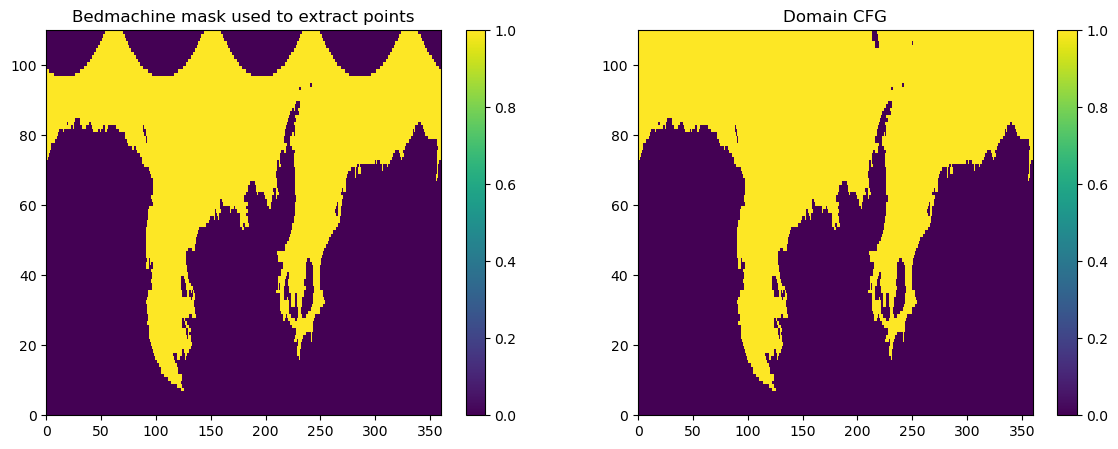

In [5]:
fig, ax = plt.subplots(1,2, figsize = (14,5))
im = [[],[]]
im[1] = ax[1].pcolor(CFG.bottom_level.isel(t=0)[0:110]>0)
im[0] = ax[0].pcolor(bmach.mask_nocavs==1)
titles = 'Bedmachine mask used to extract points', 'Domain CFG'
for i in range(2):
    plt.colorbar(im[i], ax = ax[i])
    ax[i].set_title(titles[i])

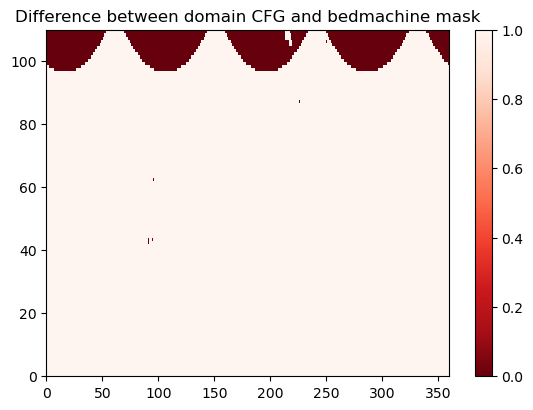

In [6]:
fig, ax = plt.subplots(1,1, figsize = (6.5,4.5))
im = ax.pcolor((CFG.bottom_level.isel(t=0)[0:110].values>0) == (bmach.mask_nocavs.values==1), cmap = 'Reds_r')
ax.set_title('Difference between domain CFG and bedmachine mask')
plt.colorbar(im, ax = ax)

In [7]:
# Make sure that the mask used to select points matches with the domain CFG 
array = (CFG.bottom_level.isel(t=0)[0:110] >0).values
array = array.astype('float32')
array[array == False] = np.nan
bmach['mask_nocavs'] = (("y", "x"), array) 

/tmp/ipykernel_295665/3420934228.py:7: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im[i], ax = ax[i])


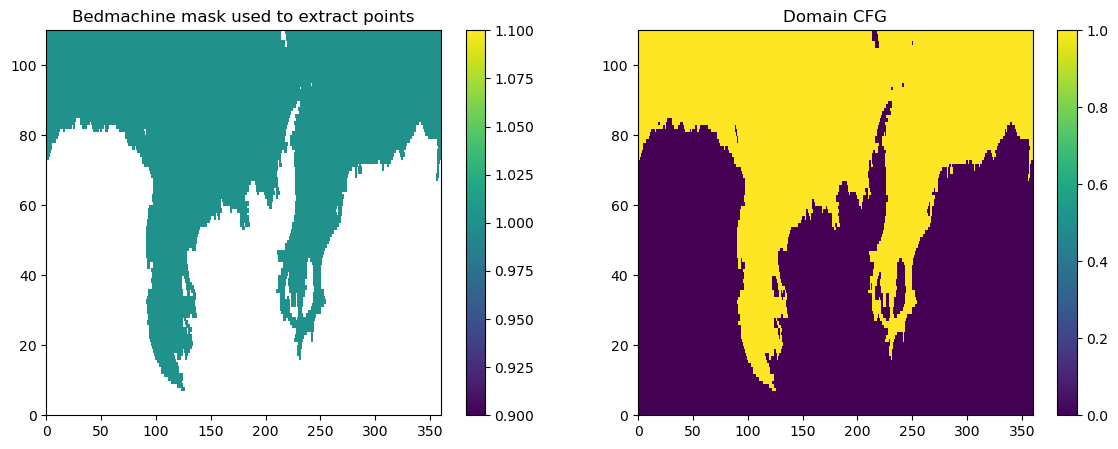

In [8]:
fig, ax = plt.subplots(1,2, figsize = (14,5))
im = [[],[]]
im[1] = ax[1].pcolor(CFG.bottom_level.isel(t=0)[0:110]>0)
im[0] = ax[0].pcolor(bmach.mask_nocavs)
titles = 'Bedmachine mask used to extract points', 'Domain CFG'
for i in range(2):
    plt.colorbar(im[i], ax = ax[i])
    ax[i].set_title(titles[i])

In [9]:
# Save new CFG file to specified filepath
bmach.to_netcdf(filepath_eORCA1_bmach_masks_new)
print('You have saved: ', filepath_eORCA1_bmach_masks_new)

You have saved:  /bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc


## THE NEXT TASK is to redo the main mask so that it matches the new area but the old mask values?

In [10]:
# Load in both of the previous masks 

In [11]:
# The target grid mask 
filepath_mask_b3 = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
# The target grid geometry
filepath_geomvars_b3 = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'

# Open these masks
mask_b3 = xr.open_dataset(filepath_mask_b3)
mask_b2 = xr.open_dataset(filepath_mask)
geoms_b3 = xr.open_dataset(filepath_geomvars_b3)
geoms_b2 = xr.open_dataset(filepath_geomvars)

In [12]:
# Fields that are already okay 
# basins_NEMO

In [13]:
mask_b3.coords

Coordinates:
    lon      (y, x) float32 3MB ...
    lat      (y, x) float32 3MB ...

In [14]:
list(mask_b3.data_vars)

['ocean_only',
 'ocean_only_nan',
 'all_cavities',
 'all_cavities_nan',
 'closed_cavities',
 'closed_cavities_nan',
 'open_cavities',
 'open_cavities_nan',
 'ocean_open_cavities',
 'ocean_open_cavities_nan',
 'grounded_ice',
 'grounded_ice_nan',
 'basins_NEMO']

In [15]:
inboth = ((mask_b3.closed_cavities == 1) & (mask_b2.closed_cavities == 1)).values
inboth = inboth.astype('float32')
inboth[inboth == 0] = np.nan
innew = ((mask_b3.closed_cavities == 1) & (mask_b2.closed_cavities == 0)).values
innew = innew.astype('float32')
innew[innew == 0] = np.nan
inold = ((mask_b3.closed_cavities == 0) & (mask_b2.closed_cavities == 1)).values
inold = inold.astype('float32')
inold[inold == 0] = np.nan

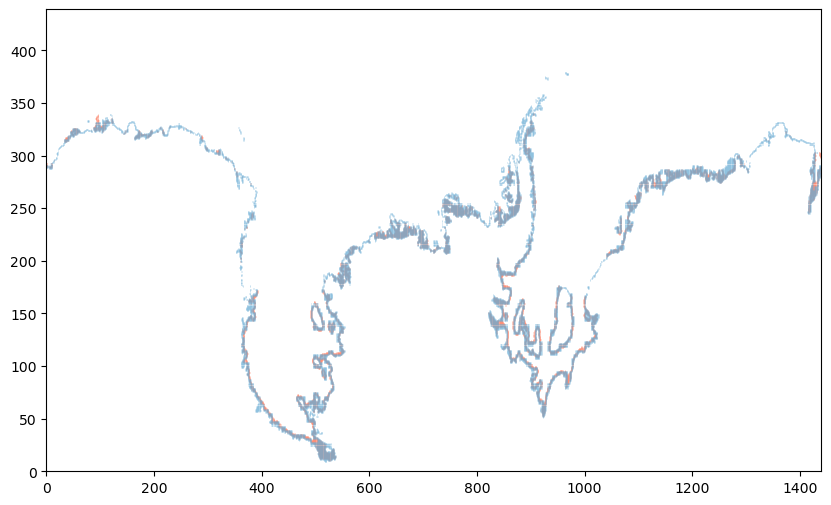

In [16]:
fig, ax = plt.subplots(1,1, figsize = (10,6))
#plt.pcolor(inboth, cmap = 'Purples', vmin = 0.4, vmax = 1.4, zorder = 0)
plt.pcolor(mask_b3.closed_cavities_nan, cmap = 'Blues', vmin = 0.5, vmax = 1.5, alpha = 0.2, zorder = 1)
plt.pcolor(mask_b2.closed_cavities_nan, cmap = 'Reds', vmin = 0.5, vmax = 1.5, alpha = 0.2, zorder = 0)

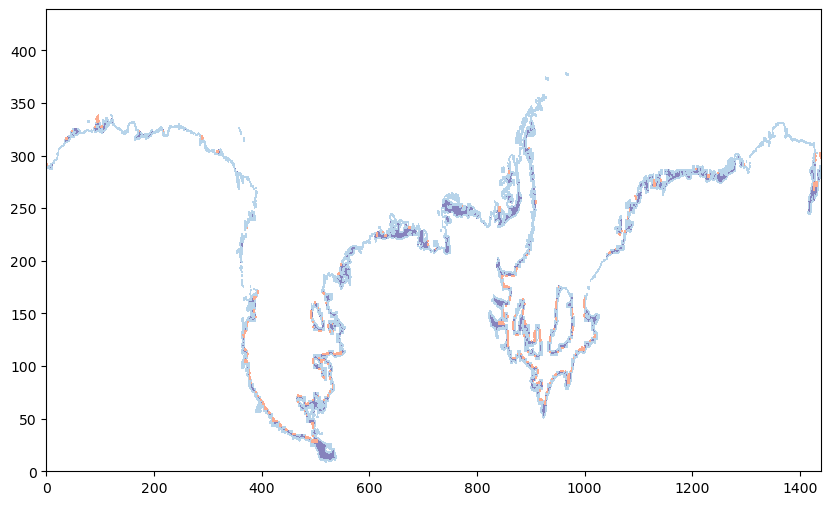

In [17]:
fig, ax = plt.subplots(1,1, figsize = (10,6))
plt.pcolor(inboth, cmap = 'Purples', vmin = 0.4, vmax = 1.4, zorder = 0)
plt.pcolor(innew, cmap = 'Blues', vmin = 0.7, vmax = 1.7, zorder = 0)
plt.pcolor(inold, cmap = 'Reds', vmin = 0.7, vmax = 1.7, zorder = 0)

In [18]:
np.sum((mask_b3.closed_cavities & mask_b2.closed_cavities)*geoms_b2.areas)

<xarray.DataArray ()> Size: 8B
array(5.13058511e+11)

In [19]:
np.sum((mask_b3.closed_cavities)*geoms_b2.areas)

<xarray.DataArray ()> Size: 8B
array(1.06112376e+12)

In [20]:
np.sum((mask_b2.closed_cavities)*geoms_b2.areas)

<xarray.DataArray ()> Size: 8B
array(5.53058187e+11)